# Docker Networking

Docker networking is the system that allows containers to communicate with:

Other containers

The Docker host

Other hosts (in multi-host deployments)

External networks (Internet)

# 1. Bridge Network (default)

When you install Docker, it creates a default bridge network.

* docker network ls

# Output:

NETWORK ID     NAME      DRIVER

abc123         bridge    bridge

def456         host      host

ghi789         none      null

# Run a container:

docker run -d --name web nginx

# Inspect its IP:

docker inspect web

# Example:

IPAddress: 172.17.0.2

The host can access it through port mapping:

docker run -d -p 8080:80 nginx

* Now:

Host:8080  --->  Container:80

# Bridge network Docker ka default network driver hai jo same host (same machine) par chal rahe containers ko aapas me communicate karne deta hai.

Machine
│
├── Container A
├── Container B
└── Container C

Sab Bridge Network se connected hain

# Kab use hota hai?
Single server

Microservices

Web + Database

Development environment

In [ ]:
# Example:

Frontend
     │
Backend
     │
Database

Sab ek hi bridge network par

# Communication

Agar containers same bridge network me hain:

✅ Communicate kar sakte hain.

Container A  ---> Container B

Agar different networks me hain:

❌ Communicate nahi kar sakte (jab tak explicitly connect na kiya jaye).

# Bridge network default kyun hota hai?

Docker ka main purpose hai containers ko easily run karna. Jab Docker install hota hai, to woh automatically ek bridge network bana deta hai taaki har container ko basic networking mil jaye, bina kisi extra configuration ke.

# Socho agar bridge network na hota...
docker run nginx

Docker ko pata hi nahi hota:

Container ko IP kaise dena hai?

Internet kaise dena hai?

Dusre containers se kaise connect karna hai?

Isliye Docker pehle se hi ek default bridge network create karta hai.

# Kaise kaam karta hai?

Jab tum run karte ho:

docker run -d nginx

Docker automatically:

Container create karta hai.

Default bridge network se connect karta hai.

Container ko ek private IP deta hai.

In [ ]:
# Example:

Host Machine
      │
 Default Bridge Network
      │
 ┌─────────────┐
 │ nginx       │
 │172.17.0.2   │
 └─────────────┘

Tumhe kuch bhi manually nahi karna padta.

# Bridge is the default Docker network because every container needs basic networking immediately after it starts. Docker automatically connects new containers to the default bridge network, assigns them a private IP address, and provides Internet connectivity through NAT. This allows containers on the same host to communicate without requiring manual network configuration.

# User-defined Bridge Network

User-defined bridge network ek custom network hota hai jo user khud create karta hai. Is network me jo containers hote hain, wo easily ek dusre se communicate kar sakte hain.

Create karne ka command:

docker network create my-network

#Iski zarurat kyu hai?

Default bridge network me kuch limitations hoti hain.

User-defined bridge network ke benefits:

1. Automatic DNS (Sabse Important)

Containers ek dusre ko container name se access kar sakte hain.

2. Better Isolation

Sirf wahi containers communicate kar sakte hain jo same user-defined network me hain.

3. Easy Management

Running container ko bhi network se connect ya disconnect kar sakte ho.

4. Best for Microservices

Sab same network me hain, to frontend backend ko backend naam se call kar sakta hai aur backend database ko database naam se.

IP address use karne ki zarurat nahi hoti.

# A user-defined bridge network is a custom Docker network created by the user using docker network create. It allows containers on the same host to communicate using container names instead of IP addresses because Docker provides automatic DNS. It also offers better isolation, easier management, and is recommended for real-world applications and microservices.

# Host Network
Host network me container host machine ka network directly use karta hai

Isme container ka alag IP address nahi hota.

Container aur host same network namespace share karte hain.

# Run command:

docker run --network host nginx

# Kaise kaam karta hai?
Host ka port hi container ka port ban jata hai.

# Example:

Host:

Port 80

Container:

Nginx running on Port 80

Run:

docker run --network host nginx

Ab browser me:

http://localhost

Seedha container open ho jayega.

# Host network means the container shares the host machine's network stack. It does not get its own IP address and does not require port mapping. Because there is no network isolation, it provides better performance but is less secure and can cause port conflicts if the host is already using the same port.

# None Network

None network me container ko koi networking hi nahi milti.

Matlab:

❌ No Internet

❌ No container-to-container communication

❌ No external access

Container completely isolated hota hai.

# Run command:

docker run --network none alpine

# Kaise kaam karta hai?

Normally container ke paas hota hai:

Network Interface (eth0)

IP Address

Gateway

Lekin none network me:

Sirf loopback (localhost)

No eth0

No IP

Matlab container sirf khud ke andar kaam kar sakta hai.

# None network in Docker is a network mode where the container has no networking at all. It does not get any IP address, cannot access the internet, and cannot communicate with other containers. It is mainly used for maximum isolation and secure or offline workloads.

# Docker Volumes & Storage

Docker me storage ka concept hota hai kyunki containers temporary (ephemeral) hote hain.

Matlab:

👉 Container delete = data bhi delete ❌ (by default)

Is problem ko solve karta hai Docker Storage system.


# 1. Docker Storage Types

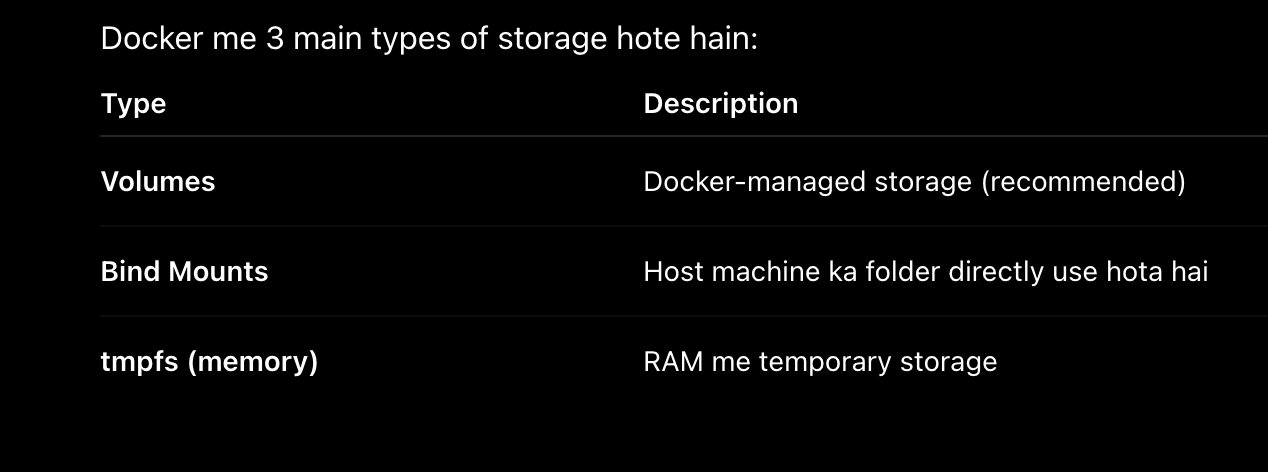

# 2. Docker Volume
Volume = Docker ka managed storage system


Docker khud data store karta hai:

/var/lib/docker/volumes/

# Create Volume
docker volume create my-volume

# Use Volume
docker run -d \
  --name myapp \
  -v my-volume:/app/data \
  nginx

  #Important Point

Agar container delete bhi ho jaye:

docker rm myapp

👉 data still safe रहेगा (volume me) ✅

# 3. Bind Mount (Host Storage)

Host machine ka folder directly container me attach hota hai.

docker run -v /home/user/data:/app/data nginx



# Why Volumes are Important?

Containers are stateless:

Container dies → data gone ❌

Volumes make them stateful:

Container dies → data safe in volume ✅

# Useful Commands

# List volumes:

docker volume ls

# Inspect volume:

docker volume inspect my-volume

# Remove volume:

docker volume rm my-volume

# Remove unused volumes:

docker volume prune

# Docker volumes are persistent storage mechanisms managed by Docker that allow data to survive container restarts or deletion. Unlike containers which are ephemeral, volumes store data outside the container lifecycle and are recommended for production use, especially for databases.

# Docker Compose

Docker Compose ek tool hai jo multiple containers ko ek saath manage karne ke liye use hota hai.

Simple words me:

👉 Ek hi file se poora application stack run kar sakte ho.

# Problem without Compose

Socho tumhara app hai:

Frontend (React)

Backend (Node)

Database (Postgres)

Normally tum ye commands chalate:

docker run frontend

docker run backend

docker run postgres

👉 Bohot messy + hard to manage ❌

# Solution: Docker Compose

# Ek file banate ho:

docker-compose.yml

# Aur bas ek command:

docker compose up

👉 Sab containers ek saath start ho jate hain ✅

# 1. Basic Docker Compose File

In [ ]:
version: "3.8"

services:
  frontend:
    image: nginx
    ports:
      - "8080:80"

  backend:
    image: node
    ports:
      - "3000:3000"

  db:
    image: postgres
    environment:
      POSTGRES_PASSWORD: secret

# 2. Structure

In [ ]:
docker-compose.yml
   │
   ├── services
   │     ├── frontend
   │     ├── backend
   │     └── database

# 3. Run Command

In [ ]:
docker compose up

In [ ]:
# Background me run:

docker compose up -d

In [ ]:
# Stop all:

docker compose down

# Important Keywords

In [ ]:
| Keyword     | Meaning                     |
| ----------- | --------------------------- |
| services    | Containers define karta hai |
| image       | Docker image                |
| build       | Local Dockerfile se build   |
| ports       | Port mapping                |
| environment | Env variables               |
| volumes     | Data storage                |
| depends_on  | Startup order               |


# Depends On (Important)
depends_on:
  - db

👉 matlab pehle db start hoga, fir app.

# Docker Compose is a tool used to define and run multi-container Docker applications using a single YAML file. It allows you to configure services like frontend, backend, and database together, automatically manages networking, and simplifies deployment using a single command like docker compose up.

# What is YAML file

YAML Ain’t Markup Language

YAML ek aisi file hoti hai jisme hum data ko simple text + indentation (spaces) se structure karte hain.

Docker Compose (docker-compose.yml)

Kubernetes (deployment.yaml)

CI/CD pipelines (GitHub Actions)

# Basic YAML Example

name: Yash

age: 22

city: Delhi

👉 Isme:

key: value format hota hai

JSON jaisa hai, but more readable

In [ ]:
YAML in Docker Compose

version: "3.8"

services:
  app:
    image: nginx
    ports:
      - "8080:80"

👉 Isme hum multiple containers define karte hain.

# Ek command:

docker compose up

# Docker Registry

Docker Registry ek storage system hota hai jahan Docker images store aur share ki jaati hain.

Registry = Docker images ka “Google Drive / Library”



# Types of Docker Registry

# 1. Docker Hub (Most Common)

👉 Public registry by Docker

https://hub.docker.com

Example:

docker pull nginx

👉 Nginx image Docker Hub se aati hai

# 2. Private Registry

Companies apni images secure rakhne ke liye use karti hain.

Example:

AWS ECR

Google GCR

Azure ACR

# 3. Self-hosted Registry

Tum khud ka registry server bana sakte ho:

docker run -d -p 5000:5000 registry

# Multi-Stage Docker Builds

Multi-stage build ek technique hai jisme hum Docker image ko multiple steps (stages) me build karte hain, aur final image ko lightweight aur clean banate hain.



# 1. Problem without Multi-Stage Builds

Agar tum normal Dockerfile use karte ho:

FROM node:18

WORKDIR /app

COPY . .

RUN npm install

RUN npm run build

CMD ["node", "dist/index.js"]

👉 Problem:

node_modules

source code

build tools


sab final image me chala jata hai ❌

👉 Image heavy ho jati hai (500MB+)

# 2. Solution: Multi-Stage Build

👉 Isme hum 2 stages banate hain:

Stage 1: Build stage

code compile hota hai

dependencies install hoti hain

Stage 2: Production stage

sirf required output copy hota hai

# 3. Example (Node.js App)


In [ ]:

# Stage 1: Build stage
FROM node:18 AS builder

WORKDIR /app
COPY package*.json ./
RUN npm install

COPY . .
RUN npm run build


# Stage 2: Production stage
FROM node:18-alpine

WORKDIR /app

# Sirf build output copy karo
COPY --from=builder /app/dist ./dist
COPY --from=builder /app/node_modules ./node_modules
COPY package*.json ./

CMD ["node", "dist/index.js"]

# Monitoring & Logging in Docker

Docker me monitoring aur logging ka main goal hota hai:

👉 containers ke andar kya ho raha hai, kaise performance hai, aur errors kya aa rahe hain — sab track karna.

#  Logging

Container ke andar jo output (logs) aata hai usko capture karna.

# Example:

app logs

error logs

request logs

# Monitoring
Container ka performance + health + resource usage track karna



# Docker Orchestration
Docker orchestration ka matlab hota hai multiple containers ko automatically manage karna (deploy, scale, connect, monitor).

* Jab tumhare paas bahut saare containers ho (microservices), unko manually handle karna hard hota hai. Orchestration tools ye kaam automatically kar dete hain.